# Notebook 8 — Poster Figures & Final Results

This notebook turns the completed experiments into **poster-ready figures, tables, and concise findings**.

### Main outputs
1. Model comparison — Test Macro F1
2. Model comparison — Test Accuracy
3. Data-efficiency learning curve
4. Per-class F1 comparison
5. DistilBERT confusion matrix
6. Error rate by text length
7. Computational-cost comparison
8. Compact poster results table
9. Poster results table and limitations

### Important consistency note
The **main three-model comparison** uses the direct final runs from Notebooks 3–5.

The **data-efficiency experiment** was run separately at 10%, 25%, 50%, 75%, and 100% training data. Its 100% BiLSTM result is 0.6546 Macro F1, whereas the direct BiLSTM run used for the main comparison is 0.6425. These are separate training runs, so they should **not be mixed into one comparison table**. The data-efficiency figure is presented as its own experiment.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Find the project data directory from the notebook location.
possible_data_dirs = [
    Path("data"),
    Path("../data"),
    Path("../../data")
]

DATA_DIR = None

for path in possible_data_dirs:
    if (path / "results").exists():
        DATA_DIR = path
        break

if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not find the data folder. Run this notebook from the project root "
        "or from the Experiment/notebooks folder."
    )

RESULTS_DIR = DATA_DIR / "results"
FIGURES_DIR = DATA_DIR.parent / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)



## Load the completed experiment results

The main comparison is based on the direct model runs:

- TF-IDF + Logistic Regression
- BiLSTM
- DistilBERT

The primary metric is **test Macro F1**, because the dataset is imbalanced across the eight classes.


In [2]:
def load_result_file(filename):
    path = RESULTS_DIR / filename
    if not path.exists():
        raise FileNotFoundError(f"Missing result file: {path}")
    return pd.read_csv(path)

tfidf_results = load_result_file("tfidf_logistic_regression_results.csv")
bilstm_results = load_result_file("bilstm_results.csv")
distilbert_results = load_result_file("distilbert_results.csv")

print("TF-IDF columns:", tfidf_results.columns.tolist())
print("BiLSTM columns:", bilstm_results.columns.tolist())
print("DistilBERT columns:", distilbert_results.columns.tolist())


TF-IDF columns: ['model', 'accuracy', 'macro_precision', 'macro_recall', 'macro_f1', 'weighted_f1', 'training_time_seconds', 'n_train', 'n_validation', 'n_test', 'n_features']
BiLSTM columns: ['model', 'accuracy', 'macro_precision', 'macro_recall', 'macro_f1', 'weighted_f1', 'best_validation_macro_f1', 'training_time_seconds', 'n_train', 'n_validation', 'n_test', 'vocab_size', 'max_sequence_length', 'embedding_dim', 'hidden_dim', 'batch_size', 'epochs']
DistilBERT columns: ['model', 'accuracy', 'macro_precision', 'macro_recall', 'macro_f1', 'weighted_f1', 'best_validation_macro_f1', 'training_time_seconds', 'n_train', 'n_validation', 'n_test', 'model_name', 'max_sequence_length', 'batch_size', 'learning_rate', 'epochs', 'weight_decay']


In [3]:
# Build a compact main-comparison table.
# These are the direct model runs from Notebooks 3–5.

def get_last_row(df):
    return df.iloc[-1]


def find_metric_column(df, metric):
    """Find a metric column using the actual saved CSV schema."""

    candidates = {
        "accuracy": [
            "accuracy",
            "test_accuracy",
            "Test Accuracy",
            "test Accuracy"
        ],
        "macro_f1": [
            "macro_f1",
            "test_macro_f1",
            "Test Macro F1",
            "test Macro F1"
        ],
        "weighted_f1": [
            "weighted_f1",
            "test_weighted_f1",
            "Test Weighted F1",
            "test Weighted F1"
        ]
    }

    for column in candidates[metric]:
        if column in df.columns:
            return column

    raise KeyError(
        f"Could not find a column for '{metric}'. "
        f"Available columns: {df.columns.tolist()}"
    )


main_rows = []

for model_name, df in [
    ("TF-IDF + Logistic Regression", tfidf_results),
    ("BiLSTM", bilstm_results),
    ("DistilBERT", distilbert_results),
]:
    row = get_last_row(df)

    accuracy_col = find_metric_column(df, "accuracy")
    macro_f1_col = find_metric_column(df, "macro_f1")
    weighted_f1_col = find_metric_column(df, "weighted_f1")

    main_rows.append({
        "Model": model_name,
        "Test Accuracy": float(row[accuracy_col]),
        "Test Macro F1": float(row[macro_f1_col]),
        "Test Weighted F1": float(row[weighted_f1_col]),
    })


main_comparison = pd.DataFrame(main_rows)

main_comparison_display = main_comparison.copy()

for col in [
    "Test Accuracy",
    "Test Macro F1",
    "Test Weighted F1"
]:
    main_comparison_display[col] = (
        main_comparison_display[col] * 100
    ).round(2).astype(str) + "%"

display(main_comparison_display)


,Model,Test Accuracy,Test Macro F1,Test Weighted F1
0,TF-IDF + Logistic Regression,75.12%,70.22%,75.24%
1,BiLSTM,71.78%,64.25%,72.27%
2,DistilBERT,78.83%,74.49%,79.08%


## Model comparison — Macro F1

This figure compares test Macro F1 across the three models.

**Poster interpretation:** Under the configurations used in these experiments, DistilBERT has the highest test Macro F1 among the three direct model runs.


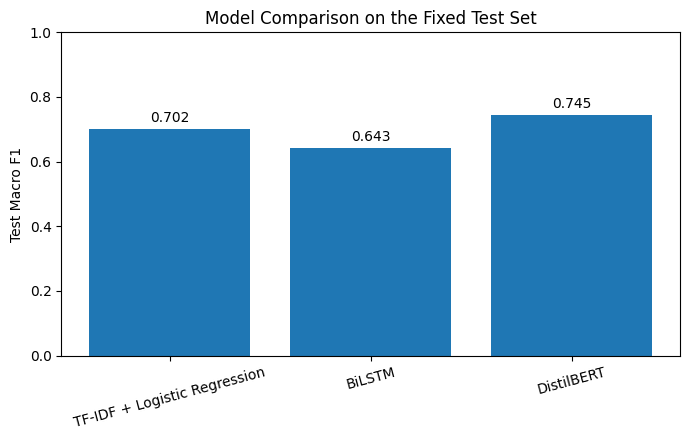

Saved: poster_model_comparison_macro_f1.png


In [4]:
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.bar(
    main_comparison["Model"],
    main_comparison["Test Macro F1"]
)

ax.set_ylabel("Test Macro F1")
ax.set_title("Model Comparison on the Fixed Test Set")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=15)

for i, value in enumerate(main_comparison["Test Macro F1"]):
    ax.text(i, value + 0.02, f"{value:.3f}", ha="center")

fig.tight_layout()

path = FIGURES_DIR / "poster_model_comparison_macro_f1.png"
fig.savefig(path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", path.name)


## Model comparison — Accuracy

Accuracy is included as a secondary metric. Macro F1 remains the primary metric because the class distribution is imbalanced.


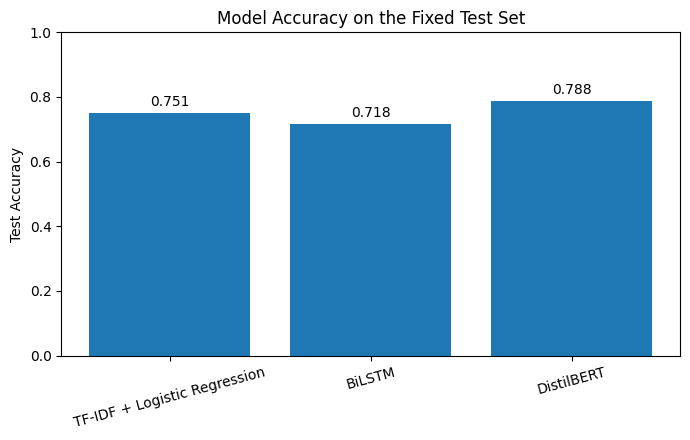

Saved: poster_model_comparison_accuracy.png


In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.bar(
    main_comparison["Model"],
    main_comparison["Test Accuracy"]
)

ax.set_ylabel("Test Accuracy")
ax.set_title("Model Accuracy on the Fixed Test Set")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=15)

for i, value in enumerate(main_comparison["Test Accuracy"]):
    ax.text(i, value + 0.02, f"{value:.3f}", ha="center")

fig.tight_layout()

path = FIGURES_DIR / "poster_model_comparison_accuracy.png"
fig.savefig(path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", path.name)


## Data efficiency

This experiment uses the same validation and test sets while increasing the training subset from:

**10% → 25% → 50% → 75% → 100%**

The purpose is to examine how performance changes with training-data size.

The 100% values here belong to the separate data-efficiency reruns and are therefore not used to replace the direct model-comparison results above.


In [6]:
efficiency = load_result_file("data_efficiency_results.csv")

print("Columns:", efficiency.columns.tolist())
display(efficiency.head())


Columns: ['model', 'fraction', 'n_train', 'val_macro_f1', 'test_accuracy', 'test_macro_precision', 'test_macro_recall', 'test_macro_f1', 'test_weighted_f1', 'training_time_seconds', 'n_features', 'vocab_size']


,model,fraction,n_train,val_macro_f1,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,test_weighted_f1,training_time_seconds,n_features,vocab_size
0,BiLSTM,0.10,3811,0.487610,0.588883,0.484853,0.550984,0.493091,0.585846,13.816366,NaN,10788.0
1,BiLSTM,0.25,9529,0.558848,0.628306,0.526296,0.600808,0.550029,0.636192,19.608994,NaN,18689.0
2,BiLSTM,0.50,19058,0.610968,0.679971,0.604445,0.655542,0.615298,0.681379,31.882184,NaN,28025.0
3,BiLSTM,0.75,28586,0.638399,0.701885,0.630974,0.678595,0.638806,0.708367,50.579724,NaN,35022.0
4,BiLSTM,1.00,38115,0.662671,0.716332,0.650854,0.691366,0.654637,0.721446,68.218806,NaN,41560.0


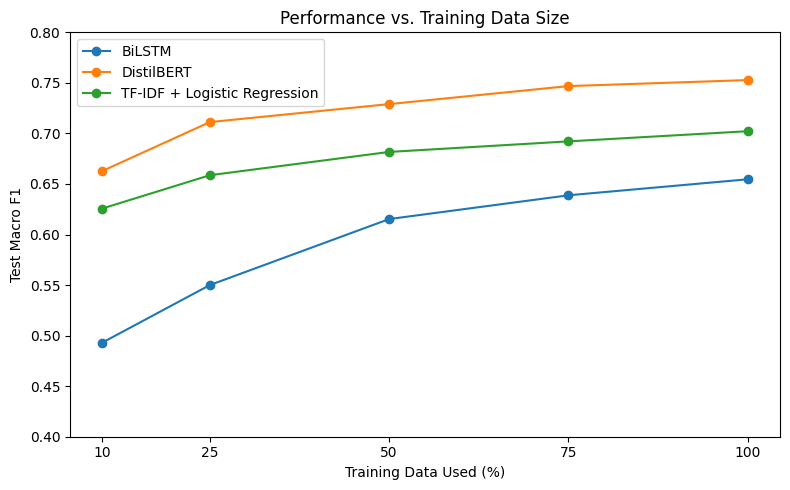

Saved: poster_data_efficiency_macro_f1.png


In [7]:
def find_efficiency_column(df, candidates, description):
    for column in candidates:
        if column in df.columns:
            return column

    raise KeyError(
        f"Could not find {description}. "
        f"Available columns: {df.columns.tolist()}"
    )


fraction_col = find_efficiency_column(
    efficiency,
    ["fraction", "data_fraction", "train_fraction"],
    "the training-data fraction column"
)

macro_col = find_efficiency_column(
    efficiency,
    ["test_macro_f1", "macro_f1", "Test Macro F1"],
    "the test Macro F1 column"
)

model_col = find_efficiency_column(
    efficiency,
    ["model", "Model"],
    "the model column"
)

efficiency_plot = efficiency.copy()
efficiency_plot["Training Data (%)"] = efficiency_plot[fraction_col] * 100

fig, ax = plt.subplots(figsize=(8, 5))

for model_name, group in efficiency_plot.groupby(model_col):
    group = group.sort_values(fraction_col)

    ax.plot(
        group["Training Data (%)"],
        group[macro_col],
        marker="o",
        label=model_name
    )

ax.set_xlabel("Training Data Used (%)")
ax.set_ylabel("Test Macro F1")
ax.set_title("Performance vs. Training Data Size")
ax.set_xticks([10, 25, 50, 75, 100])
ax.set_ylim(0.4, 0.8)
ax.legend()

fig.tight_layout()

path = FIGURES_DIR / "poster_data_efficiency_macro_f1.png"
fig.savefig(path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", path.name)


In [8]:
efficiency_summary = (
    efficiency_plot
    .sort_values([model_col, fraction_col])
    .groupby(model_col)
    .agg(
        macro_f1_at_10_percent=(macro_col, "first"),
        macro_f1_at_100_percent=(macro_col, "last")
    )
    .reset_index()
)

efficiency_summary["absolute_gain"] = (
    efficiency_summary["macro_f1_at_100_percent"]
    - efficiency_summary["macro_f1_at_10_percent"]
)

display(efficiency_summary)

print(
    "The largest absolute Macro F1 gain in the separate data-efficiency runs "
    "can be read directly from the table above."
)


,model,macro_f1_at_10_percent,macro_f1_at_100_percent,absolute_gain
0,BiLSTM,0.493091,0.654637,0.161547
1,DistilBERT,0.662850,0.752775,0.089925
2,TF-IDF + Logistic Regression,0.625728,0.702198,0.076470


The largest absolute Macro F1 gain in the separate data-efficiency runs can be read directly from the table above.


## Per-class F1 comparison

This figure supports the error-analysis part of the poster.

The eight classes are:

Anxiety, Depression, Happy, Mentalhealth, Normal, Sad, Stress, Suicidal.


In [9]:
per_class = load_result_file("error_analysis_per_class_metrics.csv")

print("Columns:", per_class.columns.tolist())
display(per_class.head(10))


Columns: ['model', 'label', 'precision', 'recall', 'f1', 'support']


,model,label,precision,recall,f1,support
0,TF-IDF + Logistic Regression,Anxiety,0.805970,0.786026,0.795873,687
1,TF-IDF + Logistic Regression,Depression,0.784730,0.623158,0.694673,2375
2,TF-IDF + Logistic Regression,Happy,0.768421,0.715686,0.741117,102
3,TF-IDF + Logistic Regression,Mentalhealth,0.585014,0.695205,0.635368,292
4,TF-IDF + Logistic Regression,Normal,0.882987,0.919335,0.900794,2405
5,TF-IDF + Logistic Regression,Sad,0.464865,0.699187,0.558442,246
6,TF-IDF + Logistic Regression,Stress,0.497207,0.778426,0.606818,343
7,TF-IDF + Logistic Regression,Suicidal,0.676521,0.692666,0.684498,1718
8,BiLSTM,Anxiety,0.765306,0.764192,0.764749,687
9,BiLSTM,Depression,0.722328,0.637474,0.677253,2375


Per-class F1 table:


model,BiLSTM,DistilBERT,TF-IDF + Logistic Regression
label,,,
Anxiety,0.764749,0.864507,0.795873
Depression,0.677253,0.722428,0.694673
Happy,0.610000,0.793651,0.741117
Mentalhealth,0.567353,0.664596,0.635368
Normal,0.900721,0.948301,0.900794
Sad,0.483108,0.559567,0.558442
Stress,0.506818,0.698297,0.606818
Suicidal,0.630216,0.708131,0.684498


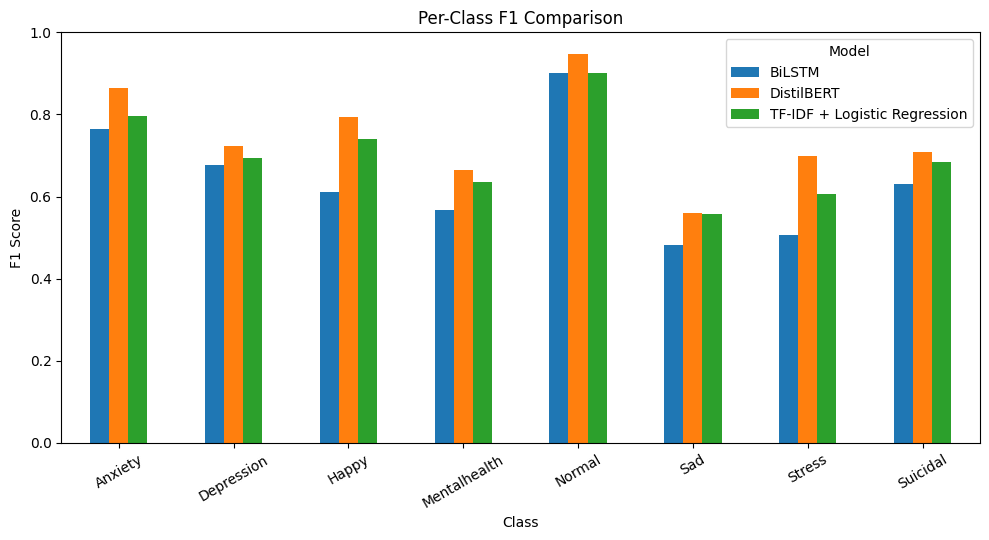

Saved: poster_per_class_f1.png


In [10]:
# Make the table robust to either long-format or already-wide output.

if {"model", "label", "f1"}.issubset(per_class.columns):
    per_class_wide = per_class.pivot(
        index="label",
        columns="model",
        values="f1"
    )
else:
    # Expected fallback if the saved table is already wide.
    per_class_wide = per_class.set_index(per_class.columns[0])

print("Per-class F1 table:")
display(per_class_wide)

fig, ax = plt.subplots(figsize=(10, 5.5))

per_class_wide.plot(
    kind="bar",
    ax=ax
)

ax.set_xlabel("Class")
ax.set_ylabel("F1 Score")
ax.set_title("Per-Class F1 Comparison")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=30)
ax.legend(title="Model")

fig.tight_layout()

path = FIGURES_DIR / "poster_per_class_f1.png"
fig.savefig(path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", path.name)


## DistilBERT confusion matrix

The confusion matrix is based directly on the saved fixed-test-set predictions.

This figure shows the main confusion patterns in the DistilBERT predictions.


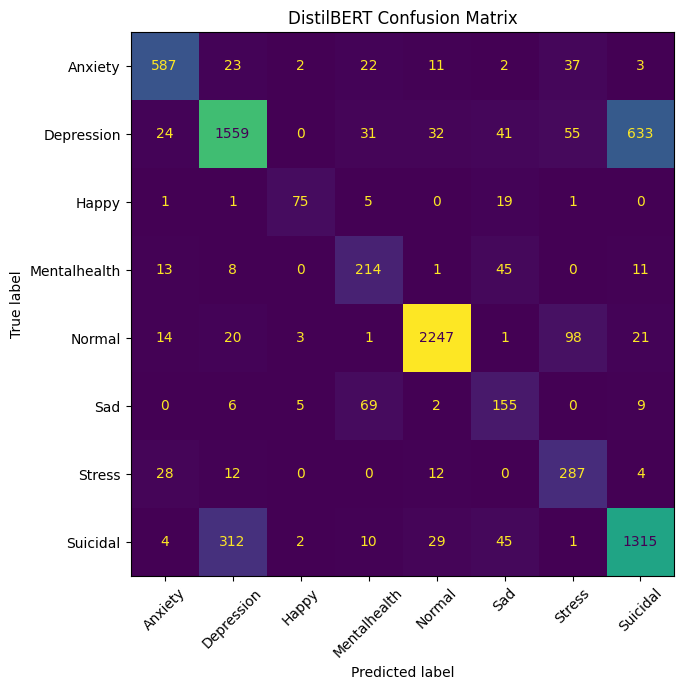

Saved: poster_distilbert_confusion_matrix.png


In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

pred_path = RESULTS_DIR / "distilbert_test_predictions.csv"

if not pred_path.exists():
    raise FileNotFoundError(f"Missing prediction file: {pred_path}")

distilbert_predictions = pd.read_csv(pred_path)

labels = [
    "Anxiety",
    "Depression",
    "Happy",
    "Mentalhealth",
    "Normal",
    "Sad",
    "Stress",
    "Suicidal"
]

cm = confusion_matrix(
    distilbert_predictions["true_label"],
    distilbert_predictions["predicted_label"],
    labels=labels
)

fig, ax = plt.subplots(figsize=(8, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    values_format="d",
    colorbar=False
)

ax.set_title("DistilBERT Confusion Matrix")
fig.tight_layout()

path = FIGURES_DIR / "poster_distilbert_confusion_matrix.png"
fig.savefig(path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", path.name)


In [12]:
# Identify the strongest off-diagonal confusion pairs.
cm_without_diagonal = cm.copy()
np.fill_diagonal(cm_without_diagonal, 0)

pairs = []

for i, true_label in enumerate(labels):
    for j, predicted_label in enumerate(labels):
        if i != j and cm_without_diagonal[i, j] > 0:
            pairs.append({
                "True label": true_label,
                "Predicted label": predicted_label,
                "Count": int(cm_without_diagonal[i, j])
            })

top_pairs = (
    pd.DataFrame(pairs)
    .sort_values("Count", ascending=False)
    .head(10)
)

display(top_pairs)


,True label,Predicted label,Count
12,Depression,Suicidal,633
40,Suicidal,Depression,312
28,Normal,Stress,98
32,Sad,Mentalhealth,69
11,Depression,Stress,55
44,Suicidal,Sad,45
21,Mentalhealth,Sad,45
10,Depression,Sad,41
5,Anxiety,Stress,37
9,Depression,Normal,32


## Error rate by text length

This is a descriptive analysis of the fixed test set.

Length groups:
- ≤32 tokens
- 33–64
- 65–128
- >128

The figure should be described as an **association in this test set**, not as evidence that text length causes errors.


In [13]:
length_results = load_result_file("error_analysis_text_length.csv")

print("Columns:", length_results.columns.tolist())
display(length_results.head(12))


Columns: ['length_bin', 'n_examples', 'errors', 'error_rate', 'macro_f1', 'model']


,length_bin,n_examples,errors,error_rate,macro_f1,model
0,≤32,3175,495,0.155906,0.634333,TF-IDF + Logistic Regression
1,33–64,1175,373,0.317447,0.705475,TF-IDF + Logistic Regression
2,65–128,1662,577,0.347172,0.632321,TF-IDF + Logistic Regression
3,>128,2156,587,0.272263,0.590756,TF-IDF + Logistic Regression
4,≤32,3175,537,0.169134,0.580371,BiLSTM
5,33–64,1175,414,0.352340,0.627310,BiLSTM
6,65–128,1662,624,0.375451,0.590159,BiLSTM
7,>128,2156,730,0.338590,0.512667,BiLSTM
8,≤32,3175,353,0.111181,0.712657,DistilBERT
9,33–64,1175,302,0.257021,0.759566,DistilBERT


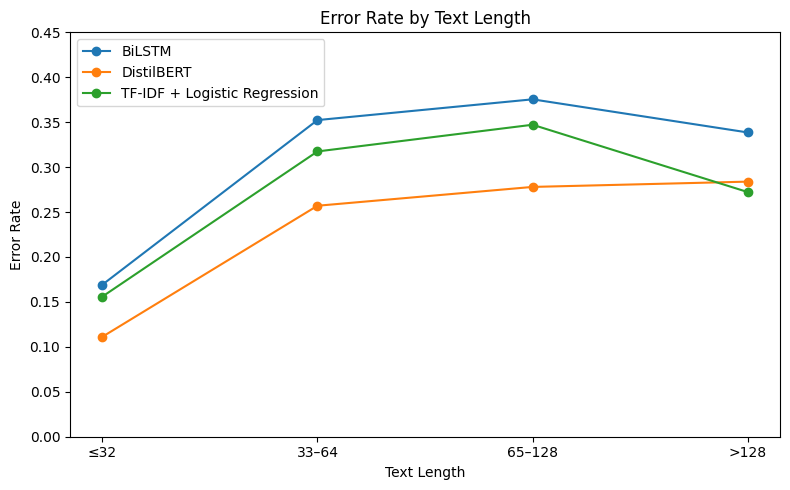

Saved: poster_error_rate_text_length.png


In [14]:
# Expected long-format columns: model, length_bin, error_rate
# The code also prints the table first so any naming mismatch is easy to diagnose.

required = {"model", "length_bin", "error_rate"}

if not required.issubset(length_results.columns):
    raise ValueError(
        f"Expected columns {required}, but found {set(length_results.columns)}"
    )

length_plot = length_results.copy()

fig, ax = plt.subplots(figsize=(8, 5))

for model_name, group in length_plot.groupby("model"):
    group = group.copy()

    # Preserve the natural text-length order.
    order = ["≤32", "33–64", "65–128", ">128"]
    group["length_order"] = group["length_bin"].apply(
        lambda x: order.index(x) if x in order else 99
    )
    group = group.sort_values("length_order")

    ax.plot(
        group["length_bin"],
        group["error_rate"],
        marker="o",
        label=model_name
    )

ax.set_xlabel("Text Length")
ax.set_ylabel("Error Rate")
ax.set_title("Error Rate by Text Length")
ax.set_ylim(0, max(0.45, length_plot["error_rate"].max() + 0.05))
ax.legend()

fig.tight_layout()

path = FIGURES_DIR / "poster_error_rate_text_length.png"
fig.savefig(path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", path.name)


## Computational cost

The data-efficiency experiment also recorded training time.

This is useful for the discussion section because the models differ substantially in computational cost. The values are experiment-specific and depend on the hardware/software environment.


In [15]:
cost = load_result_file("data_efficiency_computational_cost.csv")

print("Columns:", cost.columns.tolist())
display(cost)


Columns: ['model', 'fraction', 'n_train', 'training_time_seconds', 'training_time_minutes']


,model,fraction,n_train,training_time_seconds,training_time_minutes
0,BiLSTM,0.10,3811,13.816366,0.230273
1,BiLSTM,0.25,9529,19.608994,0.326817
2,BiLSTM,0.50,19058,31.882184,0.531370
3,BiLSTM,0.75,28586,50.579724,0.842995
4,BiLSTM,1.00,38115,68.218806,1.136980
5,DistilBERT,0.10,3811,280.916737,4.681946
6,DistilBERT,0.25,9529,505.028504,8.417142
7,DistilBERT,0.50,19058,881.424838,14.690414
8,DistilBERT,0.75,28586,1258.131642,20.968861
9,DistilBERT,1.00,38115,1642.267658,27.371128


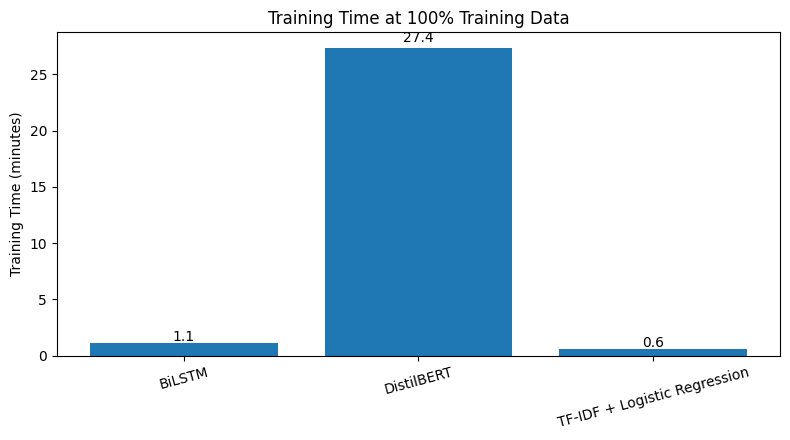

Saved: poster_training_time.png


In [16]:
# Plot full-data training time if the expected columns are available.

model_col = "model" if "model" in cost.columns else "Model"

time_candidates = [
    "training_time_seconds",
    "training_time",
    "Training Time (seconds)"
]

time_col = None
for column in time_candidates:
    if column in cost.columns:
        time_col = column
        break

if time_col is not None:
    full_cost = cost.copy()

    if "fraction" in full_cost.columns:
        full_cost = full_cost[full_cost["fraction"] == 1.0]

    elif "data_fraction" in full_cost.columns:
        full_cost = full_cost[full_cost["data_fraction"] == 1.0]

    fig, ax = plt.subplots(figsize=(8, 4.5))

    ax.bar(
        full_cost[model_col],
        full_cost[time_col] / 60
    )

    ax.set_ylabel("Training Time (minutes)")
    ax.set_title("Training Time at 100% Training Data")
    ax.tick_params(axis="x", rotation=15)

    for i, value in enumerate(full_cost[time_col] / 60):
        ax.text(
            i,
            value + max(value * 0.02, 0.2),
            f"{value:.1f}",
            ha="center"
        )

    fig.tight_layout()

    path = FIGURES_DIR / "poster_training_time.png"
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", path.name)

else:
    print(
        "No training-time column was found. "
        "Available columns:",
        cost.columns.tolist()
    )


## Compact poster results table

This table summarizes the main test-set results.


In [17]:
poster_table = main_comparison.copy()

poster_table["Accuracy"] = (
    poster_table["Test Accuracy"] * 100
).round(2).astype(str) + "%"

poster_table["Macro F1"] = (
    poster_table["Test Macro F1"] * 100
).round(2).astype(str) + "%"

poster_table["Weighted F1"] = (
    poster_table["Test Weighted F1"] * 100
).round(2).astype(str) + "%"

poster_table = poster_table[
    ["Model", "Accuracy", "Macro F1", "Weighted F1"]
]

display(poster_table)

poster_table.to_csv(
    RESULTS_DIR / "poster_main_results_table.csv",
    index=False
)

print("Saved:", RESULTS_DIR / "poster_main_results_table.csv")


,Model,Accuracy,Macro F1,Weighted F1
0,TF-IDF + Logistic Regression,75.12%,70.22%,75.24%
1,BiLSTM,71.78%,64.25%,72.27%
2,DistilBERT,78.83%,74.49%,79.08%


Saved: ..\data\results\poster_main_results_table.csv


## Limitations to state on the poster

- The comparison covers three representative approaches rather than an exhaustive benchmark.
- Results depend on the fixed dataset, split, preprocessing, hyperparameters, and random seed.
- The dataset is class-imbalanced and originates from mental-health-related text, so Macro F1 is emphasized.
- Some classes are semantically close, producing concentrated confusion between categories such as Depression and Suicidal.
- Error analysis is partly descriptive; manual error categories should only be reported after the sampled errors have been manually annotated.
- The computational-cost measurements are specific to the experimental hardware and software environment.
- The classifier is an NLP research prototype and should not be interpreted as a clinical diagnostic system.


In [18]:
# Final list of files generated/used by this notebook.

generated_files = [
    "poster_model_comparison_macro_f1.png",
    "poster_model_comparison_accuracy.png",
    "poster_data_efficiency_macro_f1.png",
    "poster_per_class_f1.png",
    "poster_distilbert_confusion_matrix.png",
    "poster_error_rate_text_length.png",
    "poster_training_time.png",
    "poster_main_results_table.csv",
]

print("Expected poster outputs:")

for filename in generated_files:
    if filename.endswith(".png"):
        path = FIGURES_DIR / filename
    else:
        path = RESULTS_DIR / filename

    print(" -", filename)


Expected poster outputs:
 - poster_model_comparison_macro_f1.png
 - poster_model_comparison_accuracy.png
 - poster_data_efficiency_macro_f1.png
 - poster_per_class_f1.png
 - poster_distilbert_confusion_matrix.png
 - poster_error_rate_text_length.png
 - poster_training_time.png
 - poster_main_results_table.csv
